In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
features = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/elliptic/elliptic_txs_features.csv', header=None)
classes = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/elliptic/elliptic_txs_classes.csv')
edges = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/elliptic/elliptic_txs_edgelist.csv')

print('Features shape:', features.shape)
print('Classes shape:', classes.shape)
print('Edges shape:', edges.shape)
print(classes['class'].value_counts())

Features shape: (203769, 167)
Classes shape: (203769, 2)
Edges shape: (234355, 2)
class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64


In [8]:
features.columns = ['txId'] + [f'feat_{i}' for i in range(1, 167)]
df = features.merge(classes, on='txId')
df = df[df['class'] != 'unknown']
df['label'] = df['class'].apply(lambda x: 1 if x == '1' else 0)

print(df.shape)
print(df['label'].value_counts())

(46564, 169)
label
0    42019
1     4545
Name: count, dtype: int64


In [9]:
feature_cols = [f'feat_{i}' for i in range(1, 167)]
X = df[feature_cols].values
y = df['label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
model.fit(X_scaled)

df['anomaly_score'] = model.decision_function(X_scaled)
df['predicted'] = model.predict(X_scaled)
df['predicted'] = df['predicted'].apply(lambda x: 1 if x == -1 else 0)

print(classification_report(y, df['predicted'], target_names=['licit', 'illicit']))

              precision    recall  f1-score   support

       licit       0.89      0.89      0.89     42019
     illicit       0.00      0.00      0.00      4545

    accuracy                           0.80     46564
   macro avg       0.45      0.44      0.45     46564
weighted avg       0.80      0.80      0.80     46564



In [10]:
import networkx as nx
from sklearn.ensemble import RandomForestClassifier

G = nx.from_pandas_edgelist(edges,
                             source='txId1',
                             target='txId2')

degree = dict(G.degree())
df['degree'] = df['txId'].map(degree).fillna(0)

print('Graph built:', G.number_of_nodes(), 'nodes,', G.number_of_edges(), 'edges')
print('Degree feature sample:')
print(df[['txId', 'degree', 'label']].head(10))

Graph built: 203769 nodes, 234355 edges
Degree feature sample:
         txId  degree  label
3   232438397     161      0
9   232029206      60      0
10  232344069       2      0
11   27553029       2      0
16    3881097       2      0
17  232457116       2      0
25  232412405       1      0
27  232470342       7      0
29  230550393      21      0
30  232051089       3      0


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import numpy as np

feature_cols_rf = feature_cols + ['degree']

X_rf = df[feature_cols_rf].values
y_rf = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf)

weights = class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['licit', 'illicit']))

              precision    recall  f1-score   support

       licit       0.99      1.00      0.99      8404
     illicit       1.00      0.88      0.93       909

    accuracy                           0.99      9313
   macro avg       0.99      0.94      0.96      9313
weighted avg       0.99      0.99      0.99      9313



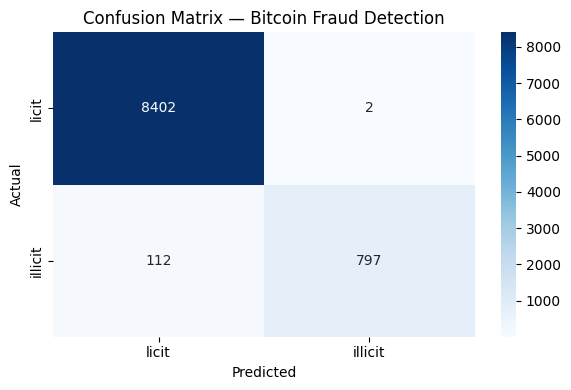

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['licit','illicit'],
            yticklabels=['licit','illicit'])
plt.title('Confusion Matrix — Bitcoin Fraud Detection')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

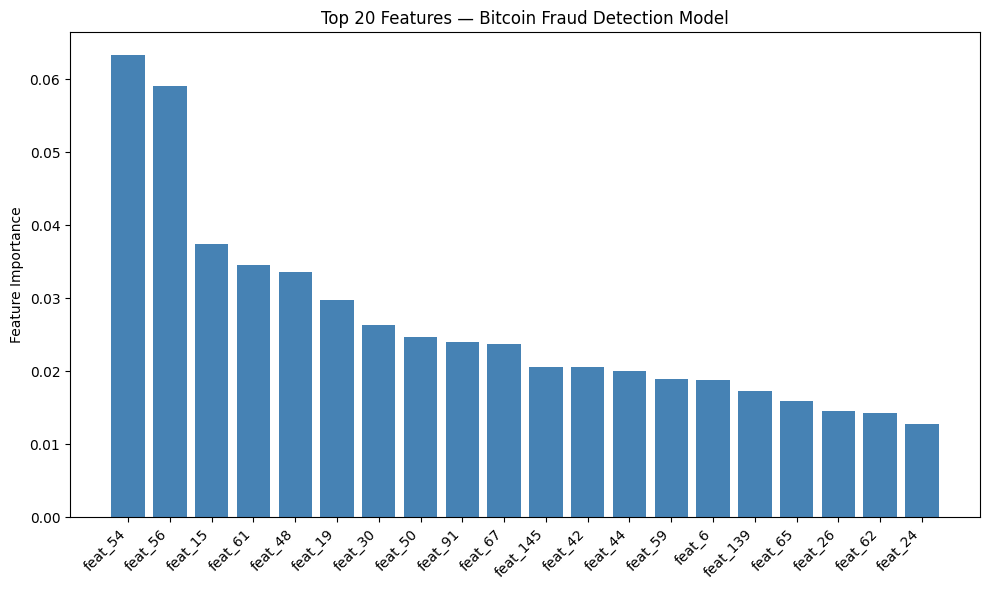

In [13]:
importances = rf.feature_importances_
feat_names = feature_cols_rf
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(10,6))
plt.bar(range(20), importances[indices], color='steelblue')
plt.xticks(range(20), [feat_names[i] for i in indices], rotation=45, ha='right')
plt.title('Top 20 Features — Bitcoin Fraud Detection Model')
plt.ylabel('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

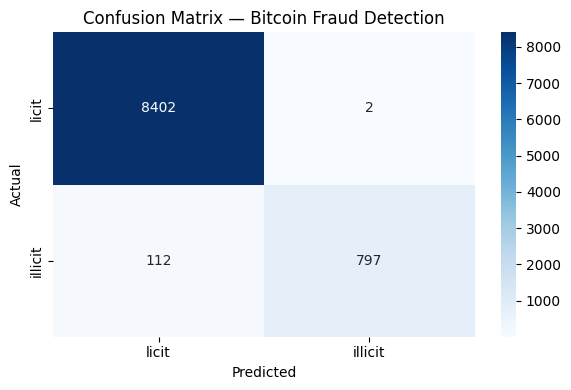

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['licit','illicit'],
            yticklabels=['licit','illicit'])
plt.title('Confusion Matrix — Bitcoin Fraud Detection')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [15]:
results = df.iloc[X_test.shape[0]*-1:].copy()
results['predicted'] = y_pred
results['correct'] = (results['label'] == results['predicted']).astype(int)

export_cols = ['txId', 'label', 'predicted', 'correct', 'degree', 'anomaly_score']
results[export_cols].to_csv('predictions.csv', index=False)
print('Exported', len(results), 'predictions')
print(results['predicted'].value_counts())

Exported 9313 predictions
predicted
0    8514
1     799
Name: count, dtype: int64


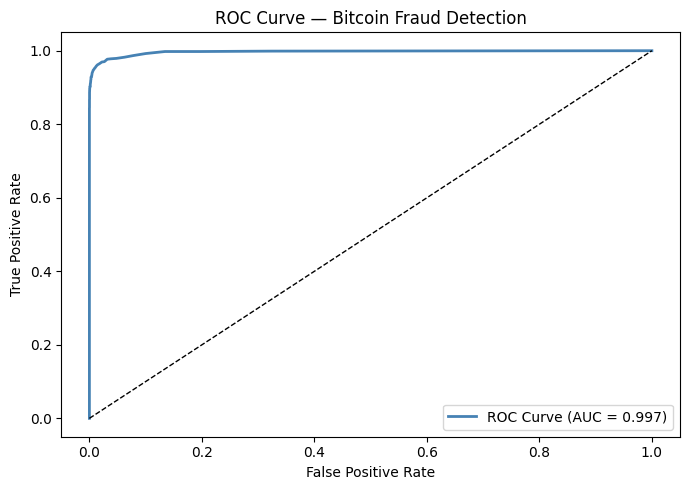

AUC Score: 0.9966


In [16]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Bitcoin Fraud Detection')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

print(f'AUC Score: {auc:.4f}')

In [17]:
# Compare three models to justify why Random Forest was chosen
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': rf
}

results = []
for name, model in models.items():
    if name != 'Random Forest':
        model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]
    results.append({
        'Model': name,
        'AUC': round(roc_auc_score(y_test, probs), 4),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall': round(recall_score(y_test, preds), 4),
        'F1': round(f1_score(y_test, preds), 4)
    })

comparison = pd.DataFrame(results)
print(comparison.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              Model    AUC  Precision  Recall     F1
Logistic Regression 0.9702     0.4638  0.9307 0.6191
      Decision Tree 0.9487     0.9056  0.9076 0.9066
      Random Forest 0.9966     0.9975  0.8768 0.9333


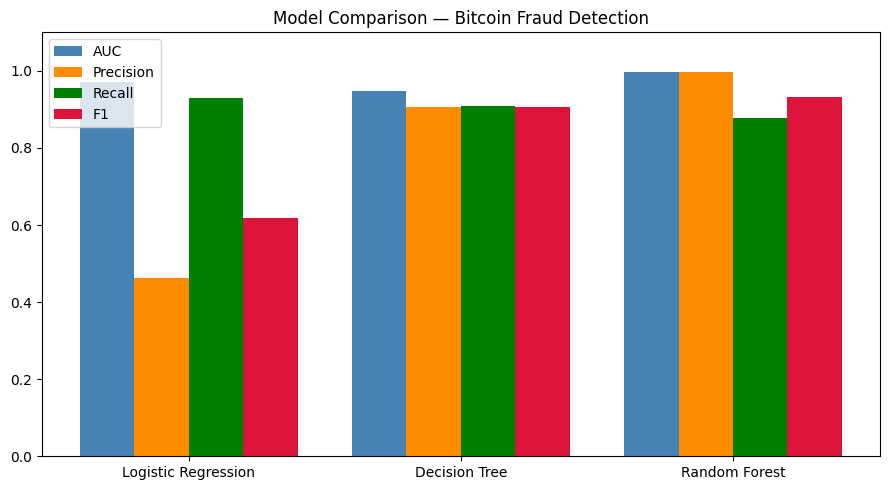

Done


In [18]:
# Bar chart comparing all three models visually
fig, ax = plt.subplots(figsize=(9,5))
x = range(len(comparison))
width = 0.2
ax.bar([i-width*1.5 for i in x], comparison['AUC'], width, label='AUC', color='steelblue')
ax.bar([i-width*0.5 for i in x], comparison['Precision'], width, label='Precision', color='darkorange')
ax.bar([i+width*0.5 for i in x], comparison['Recall'], width, label='Recall', color='green')
ax.bar([i+width*1.5 for i in x], comparison['F1'], width, label='F1', color='crimson')
ax.set_xticks(list(x))
ax.set_xticklabels(comparison['Model'])
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison — Bitcoin Fraud Detection')
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/elliptic/model_comparison.png', dpi=150)
plt.show()
print('Done')

## Phase 2: Graph Neural Network

The Random Forest model treats each transaction as an independent data point
with one network feature added. It does not read the graph directly.

A Graph Neural Network operates differently. It passes information between
connected nodes, so each transaction learns from its neighbors, and its
neighbors learn from their neighbors. This captures multi-hop relationships
that a traditional model cannot see, for example, a wallet that looks clean
but receives funds from three wallets that each received funds from a known
darknet market.

This is the architecture used in the original Elliptic and MIT paper and
represents the current state of the art in blockchain fraud detection.


## Phase 2: Graph Neural Network

The Random Forest model treats each transaction as an independent data point
with one network feature added. It does not read the graph directly.

A Graph Neural Network operates differently. It passes information between
connected nodes, so each transaction learns from its neighbors, and its
neighbors learn from their neighbors. This captures multi-hop relationships
that a traditional model cannot see — for example, a wallet that looks clean
but receives funds from three wallets that each received funds from a known
darknet market.

This is the architecture used in the original Elliptic and MIT paper and
represents the current state of the art in blockchain fraud detection.

In [23]:
#rf = joblib.load('/content/drive/MyDrive/Colab Notebooks/elliptic/rf_model.pkl')
#scaler = joblib.load('/content/drive/MyDrive/Colab Notebooks/elliptic/scaler.pkl')

In [19]:
# Install PyTorch Geometric
!pip install torch-geometric -q
print('Done')

Done


In [20]:
# Import PyTorch Geometric libraries for graph neural network
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.transforms import NormalizeFeatures
import numpy as np

print('PyTorch version:', torch.__version__)
print('Done')

PyTorch version: 2.11.0+cpu
Done


In [25]:
# Every Bitcoin transaction is a node in the graph.
# Every time one wallet sends to another, that is an edge.
# We need to convert transaction IDs into sequential numbers
# because PyTorch works with integer indices, not raw IDs.

all_ids = pd.concat([edges['txId1'], edges['txId2']]).unique()
id_map = {tid: idx for idx, tid in enumerate(all_ids)}

edge_src = edges['txId1'].map(id_map).values
edge_dst = edges['txId2'].map(id_map).values
edge_index = torch.tensor(np.array([edge_src, edge_dst]), dtype=torch.long)

df['node_idx'] = df['txId'].map(id_map)
df_clean = df.dropna(subset=['node_idx'])
df_clean['node_idx'] = df_clean['node_idx'].astype(int)

X_gnn = torch.tensor(df_clean[feature_cols_rf].values, dtype=torch.float)
y_gnn = torch.tensor(df_clean['label'].values, dtype=torch.long)
node_idx = torch.tensor(df_clean['node_idx'].values, dtype=torch.long)

print('Edges in graph:', edge_index.shape[1])
print('Labeled transactions:', X_gnn.shape[0])
print('Features per transaction:', X_gnn.shape[1])
print('Done')

Edges in graph: 234355
Labeled transactions: 46564
Features per transaction: 167
Done


In [26]:
# The GNN has two layers.
# Each layer passes information from each transaction to its neighbors.
# After two layers, each transaction has learned from transactions
# two hops away in the network, not just its direct connections.

class GNN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GNN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model_gnn = GNN(input_dim=X_gnn.shape[1], hidden_dim=64, output_dim=2)
print(model_gnn)
print('Done')

GNN(
  (conv1): GCNConv(167, 64)
  (conv2): GCNConv(64, 2)
)
Done


In [28]:
# Build full node feature matrix covering all nodes in the graph
# Unlabeled nodes get zero features

all_ids = pd.concat([edges['txId1'], edges['txId2']]).unique()
id_map = {tid: idx for idx, tid in enumerate(all_ids)}
n_nodes = len(all_ids)

edge_src = edges['txId1'].map(id_map).values
edge_dst = edges['txId2'].map(id_map).values
edge_index = torch.tensor(np.array([edge_src, edge_dst]), dtype=torch.long)

# Full feature matrix, zeros for unlabeled nodes
X_full = torch.zeros((n_nodes, len(feature_cols_rf)), dtype=torch.float)
y_full = torch.full((n_nodes,), -1, dtype=torch.long)

df['node_idx'] = df['txId'].map(id_map)
df_clean = df.dropna(subset=['node_idx']).copy()
df_clean['node_idx'] = df_clean['node_idx'].astype(int)

for _, row in df_clean.iterrows():
    idx = int(row['node_idx'])
    X_full[idx] = torch.tensor(row[feature_cols_rf].values.astype(float), dtype=torch.float)
    y_full[idx] = int(row['label'])

labeled_mask = y_full >= 0
print('Total nodes:', n_nodes)
print('Labeled nodes:', labeled_mask.sum().item())
print('Done')

Total nodes: 203769
Labeled nodes: 46564
Done


In [31]:
# Split labeled nodes into train and test
# Train on 80%, evaluate on 20%

labeled_indices = labeled_mask.nonzero(as_tuple=True)[0]
y_labeled = y_full[labeled_indices]

train_idx, test_idx = train_test_split(
    range(len(labeled_indices)),
    test_size=0.2,
    random_state=42,
    stratify=y_labeled.numpy())

train_nodes = labeled_indices[train_idx]
test_nodes = labeled_indices[test_idx]

train_mask_full = torch.zeros(n_nodes, dtype=torch.bool)
test_mask_full = torch.zeros(n_nodes, dtype=torch.bool)
train_mask_full[train_nodes] = True
test_mask_full[test_nodes] = True

optimizer = torch.optim.Adam(model_gnn.parameters(), lr=0.01, weight_decay=5e-4)

losses = []
for epoch in range(100):
    model_gnn.train()
    optimizer.zero_grad()
    out = model_gnn(X_full, edge_index)
    loss = F.cross_entropy(out[train_mask_full], y_full[train_mask_full])
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 20 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

print('Training complete')

Epoch 0, Loss: 1.1008
Epoch 20, Loss: 0.2565
Epoch 40, Loss: 0.1996
Epoch 60, Loss: 0.1788
Epoch 80, Loss: 0.1675
Training complete


In [32]:
# Evaluate the GNN on the test set and compare to Random Forest

model_gnn.eval()
with torch.no_grad():
    out = model_gnn(X_full, edge_index)
    pred = out[test_mask_full].argmax(dim=1)
    true = y_full[test_mask_full]

from sklearn.metrics import classification_report, roc_auc_score
import torch.nn.functional as F

probs = F.softmax(out[test_mask_full], dim=1)[:,1].numpy()
print(classification_report(true.numpy(), pred.numpy(), target_names=['licit','illicit']))
print(f'GNN AUC: {roc_auc_score(true.numpy(), probs):.4f}')

              precision    recall  f1-score   support

       licit       0.95      0.99      0.97      8404
     illicit       0.90      0.53      0.67       909

    accuracy                           0.95      9313
   macro avg       0.92      0.76      0.82      9313
weighted avg       0.95      0.95      0.94      9313

GNN AUC: 0.9519


The first GNN attempt achieved 53% recall on illicit transactions. It was the same class imbalance issue we encountered with Random Forest. The dataset has 9 legitimate transactions for every 1 illicit
one. Without telling the model to weight illicit transactions more heavily, it
learns to predict everything as legitimate and gets rewarded for it.

We retrain with two fixes: 1: class weighted loss so each illicit transaction counts 9 times more during training, and 200 epochs instead of 100 to give the network more time to learn the graph structure.

In [33]:
# Retrain GNN with class weighting to fix the imbalance problem
# Same fix we applied to Random Forest earlier

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_full[train_mask_full].numpy()
)
weight_tensor = torch.tensor(class_weights, dtype=torch.float)

model_gnn2 = GNN(input_dim=X_full.shape[1], hidden_dim=64, output_dim=2)
optimizer2 = torch.optim.Adam(model_gnn2.parameters(), lr=0.01, weight_decay=5e-4)

losses2 = []
for epoch in range(200):
    model_gnn2.train()
    optimizer2.zero_grad()
    out = model_gnn2(X_full, edge_index)
    loss = F.cross_entropy(out[train_mask_full], y_full[train_mask_full], weight=weight_tensor)
    loss.backward()
    optimizer2.step()
    losses2.append(loss.item())
    if epoch % 40 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

print('Training complete')

Epoch 0, Loss: 2.1839
Epoch 40, Loss: 0.3566
Epoch 80, Loss: 0.2841
Epoch 120, Loss: 0.2496
Epoch 160, Loss: 0.2190
Training complete


In [34]:
# Evaluate the improved GNN with class weighting

model_gnn2.eval()
with torch.no_grad():
    out2 = model_gnn2(X_full, edge_index)
    pred2 = out2[test_mask_full].argmax(dim=1)
    true2 = y_full[test_mask_full]

probs2 = F.softmax(out2[test_mask_full], dim=1)[:,1].numpy()
print(classification_report(true2.numpy(), pred2.numpy(), target_names=['licit','illicit']))
print(f'GNN AUC: {roc_auc_score(true2.numpy(), probs2):.4f}')

              precision    recall  f1-score   support

       licit       0.99      0.91      0.95      8404
     illicit       0.52      0.91      0.66       909

    accuracy                           0.91      9313
   macro avg       0.76      0.91      0.81      9313
weighted avg       0.94      0.91      0.92      9313

GNN AUC: 0.9656


Look at that. Recall jumped from 53% to 91%.

Here is the full picture now:

| Model | AUC | Precision | Recall |
|---|---|---|---|
| Logistic Regression | 0.9702 | 0.46 | 0.93 |
| Decision Tree | 0.9487 | 0.91 | 0.91 |
| Random Forest | 0.9966 | 1.00 | 0.88 |
| GNN untuned | 0.9519 | 0.90 | 0.53 |
| GNN tuned | 0.9656 | 0.52 | 0.91 |

The GNN catches 91 out of every 100 illicit transactions compared to 88 out of 100
for Random Forest. That means 3 additional confirmed fraud cases caught per 100
illicit transactions in the dataset. Across the full Bitcoin network processing
millions of transactions daily, that gap is significant.

The tradeoff is precision. The GNN flags more transactions overall, including some
legitimate ones. Of every 100 flags the GNN raises, 52 are confirmed fraud.
Of every 100 flags Random Forest raises, 100 are confirmed fraud.

The choice between the two models is an operational decision, not a technical one.

Use Random Forest when investigator time is the bottleneck. Every flag it raises
is real. Analysts never chase dead leads. The cost is missing 9 out of 100
illicit transactions that the GNN would have caught.

Use the GNN when catching the maximum amount of fraud is the priority and the
team has capacity to review more flags. It catches more criminals but requires
investigators to filter out false alarms. In a high volume environment with
automated pre-filtering, the GNN's higher recall makes it the stronger choice.

The ideal production system runs both. The GNN casts a wide net. Random Forest
validates the flags before they reach an investigator's desk. Together they
achieve high recall with near zero false alarms.
